# Multimodal Emotion Recognition for Mood-Based Music Recommendation

This notebook presents the end-to-end implementation of a multimodal emotion recognition system designed to support mood-based music recommendation. The pipeline evaluates three experimental settings: (1) text-based emotion classification using a pre-trained transformer, (2) speech-based emotion classification using a fine-tuned Wav2Vec2 model, and (3) a late-fusion strategy that combines both modalities within a shared five-class mood space **anger, fear, joy, neutral,** and **sadness**.

The notebook is structured to reflect the natural progression of a machine learning experiment: environment configuration, data preparation, exploratory analysis, label harmonisation, model loading, training, evaluation, and report-ready visualisation. Each section is self-contained and annotated to support reproducibility.

## Research Aims, Questions, and Objectives

**Aim:**  
To develop and evaluate a multimodal emotion recognition pipeline that predicts mood from text and speech, combines both modalities within a shared label space, and supports mood-based music recommendation.

**Research question:**  
Does combining text and audio predictions through late fusion yield stronger mood classification performance than either unimodal baseline alone?

**Objectives:**

1. Prepare the GoEmotions dataset for text-based mood prediction.
2. Prepare the RAVDESS dataset for speech-based mood prediction.
3. Map both datasets into a shared five-class mood space (anger, fear, joy, neutral, sadness).
4. Implement unimodal text and audio baseline models.
5. Apply confidence-weighted and fixed-weight late fusion to combine predictions from both modalities.
6. Compare unimodal and multimodal performance using accuracy, weighted precision, weighted recall, weighted F1-score, and normalised confusion matrices.

> **Note on proxy multimodal evaluation:** The late-fusion evaluation pairs text and audio samples that share the same mood label but do not originate from the same underlying utterance. This is an acknowledged methodological limitation and is discussed further in Section 14.

## 1. Environment Setup

The cell below pins exact library versions to ensure reproducibility across execution environments. All packages are installed as pre-built binary wheels (`--only-binary=:all:`) to avoid C-extension compilation issues on constrained platforms. The `TOKENIZERS_PARALLELISM` flag is disabled before any import to prevent a known deadlock when Hugging Face tokenisers are used inside forked worker processes.

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

%pip install --quiet --no-cache-dir --only-binary=:all: \
  "transformers==4.51.3" \
  "datasets==3.5.0" \
  "accelerate==1.6.0" \
  "librosa==0.10.1" \
  "soundfile==0.12.1" \
  "audioread==3.0.1" \
  "scikit-learn==1.3.2" \
  "huggingface_hub==0.30.2" \
  "tokenizers==0.21.1" \
  "safetensors==0.5.3" \
  "pyyaml==6.0.2" \
  "requests==2.32.3" \
  "packaging==24.2" \
  "filelock==3.18.0" \
  "regex==2024.11.6" \
  "lazy_loader==0.4" \
  "pooch==1.8.2" \
  "soxr==0.5.0.post1" \
  "msgpack==1.1.0" \
  "joblib==1.3.2" \
  "threadpoolctl==3.2.0" \
  "fsspec==2024.12.0" \
  "dill==0.3.8" \
  "multiprocess==0.70.16" \
  "xxhash==3.5.0" \
  "pyarrow==18.1.0" \
  "psutil==7.0.0"


Note: you may need to restart the kernel to use updated packages.


### 1.1 Library Version Verification

The following cell confirms that the installed library versions match the pinned requirements.

In [ ]:
import librosa
import sklearn
import transformers
import datasets
import accelerate

print(f"librosa       : {librosa.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"transformers  : {transformers.__version__}")
print(f"datasets      : {datasets.__version__}")
print(f"accelerate    : {accelerate.__version__}")


librosa       : 0.10.1
scikit-learn  : 1.3.2
transformers  : 4.51.3
datasets      : 3.5.0
accelerate    : 1.6.0


## 2. Library Imports

All third-party and standard-library imports are consolidated here. Grouping imports at the top of the notebook follows PEP 8 conventions and makes dependency tracking straightforward.

In [ ]:
import gc
import math
import os
import random
import re
import warnings
import zipfile
from collections import Counter
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    pipeline,
)

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except ImportError:
    display = print


2026-03-25 03:48:39.950099: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 03:48:45.726046: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 03:48:45.726153: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 03:48:45.726190: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 03:48:49.090940: I tensorflow/core/platform/cpu_feature_g

## 3. Reproducibility and Device Configuration

To support reproducible experiments, a global random seed is fixed across Python's `random` module, NumPy, and PyTorch. The available compute device is detected automatically; CUDA is preferred for GPU acceleration, followed by Apple MPS, with CPU as the fallback. Seeding CUDA ensures determinism on GPU where supported.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Compute device : {DEVICE}")
print(f"Global seed    : {SEED}")


Compute device : cuda
Global seed    : 42


## 4. Project Directory and Dataset Paths

This section establishes the project working directory and locates the RAVDESS audio archive. Three candidate paths are checked in order of preference; the first that exists is used. This design allows the notebook to run without modification across different execution environments (local, Colab, university HPC).

In [ ]:
PROJECT_DIR = Path("./MER_Project")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project directory : {PROJECT_DIR.resolve()}")

ZIP_CANDIDATES = [
    PROJECT_DIR / "archive.zip",
    Path("./archive.zip"),
    Path("/home/980363/MER_Project/archive.zip"),
]
ZIP_PATH = next((p for p in ZIP_CANDIDATES if p.exists()), ZIP_CANDIDATES[0])
EXTRACT_DIR = PROJECT_DIR / "audio_data"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ZIP path resolved  : {ZIP_PATH}")
print(f"Audio extract dir  : {EXTRACT_DIR.resolve()}")


Project directory : /hpc/home/980363/MER_Project
ZIP path resolved  : MER_Project/archive.zip
Audio extract dir  : /hpc/home/980363/MER_Project/audio_data


## 5. Audio File Discovery

After extracting the RAVDESS archive, this section recursively scans the full extracted directory tree and collects every valid audio file. Scanning from the extraction root, rather than selecting a single leaf directory, ensures that standard actor-folder RAVDESS layouts are loaded in full. macOS artefact files (prefixed `._`) and `__MACOSX` metadata directories are filtered out before further processing.


In [ ]:
def collect_audio_files(extract_dir, audio_exts=None):
    """Recursively collect audio files from the full extracted dataset tree."""
    audio_exts = audio_exts or {".wav", ".mp3", ".flac", ".m4a", ".ogg"}
    extract_dir = Path(extract_dir)
    return sorted(
        str(p)
        for p in extract_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in audio_exts
        and "__MACOSX" not in p.parts
        and not p.name.startswith("._")
    )


AUDIO_EXTS = {".wav", ".mp3", ".flac", ".m4a", ".ogg"}

# Extract archive only if the target directory is empty
if not any(EXTRACT_DIR.iterdir()):
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"RAVDESS archive not found. Searched: {ZIP_CANDIDATES}"
        )
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print(f"Extracted archive to : {EXTRACT_DIR}")
else:
    print(f"Using existing extracted folder : {EXTRACT_DIR}")

audio_files = collect_audio_files(EXTRACT_DIR, audio_exts=AUDIO_EXTS)
audio_parent_dirs = sorted({str(Path(p).parent) for p in audio_files})

if not audio_files:
    raise FileNotFoundError(
        f"No supported audio files were found under the extracted directory: {EXTRACT_DIR}"
    )

print(f"Audio search root   : {EXTRACT_DIR.resolve()}")
print(f"Audio files found   : {len(audio_files)}")
print(f"Parent folders seen : {len(audio_parent_dirs)}")
if audio_files:
    print("First five files:")
    for path in audio_files[:5]:
        print(f"  {path}")
if audio_parent_dirs:
    print("First five parent folders:")
    for folder in audio_parent_dirs[:5]:
        print(f"  {folder}")


Using existing extracted folder : MER_Project/audio_data
Audio search root   : /hpc/home/980363/MER_Project/audio_data
Audio files found   : 2880
Parent folders seen : 48
First five files:
  MER_Project/audio_data/archive/Actor_01/03-01-01-01-01-01-01.wav
  MER_Project/audio_data/archive/Actor_01/03-01-01-01-01-02-01.wav
  MER_Project/audio_data/archive/Actor_01/03-01-01-01-02-01-01.wav
  MER_Project/audio_data/archive/Actor_01/03-01-01-01-02-02-01.wav
  MER_Project/audio_data/archive/Actor_01/03-01-02-01-01-01-01.wav
First five parent folders:
  MER_Project/audio_data/archive/Actor_01
  MER_Project/audio_data/archive/Actor_02
  MER_Project/audio_data/archive/Actor_03
  MER_Project/audio_data/archive/Actor_04
  MER_Project/audio_data/archive/Actor_05


## 6. Load GoEmotions Text Dataset

The GoEmotions dataset (Demszky et al., 2020) is loaded directly from the Hugging Face Hub using the `simplified` configuration, which merges the original 27 fine-grained emotion categories into a reduced set. Label names are extracted from the dataset's feature schema to ensure consistent mapping in subsequent steps.

> **Dataset reference:** Demszky, D., Movshovitz-Attias, D., Ko, J., Cowen, A., Nemade, G., & Narayanan, S. (2020). GoEmotions: A dataset of fine-grained emotions. *Proceedings of ACL 2020*.

In [ ]:
go = load_dataset("go_emotions", "simplified")
label_names = go["train"].features["labels"].feature.names

print(f"GoEmotions splits       : {list(go.keys())}")
print(f"Number of original labels : {len(label_names)}")
print(f"Label names             : {label_names}")
print(f"Example training row    : {go['train'][0]}")


GoEmotions splits       : ['train', 'validation', 'test']
Number of original labels : 28
Label names             : ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Example training row    : {'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


## 7. Exploratory Data Analysis

This section conducts a targeted inspection of both datasets before any modelling takes place. For GoEmotions, label frequency, label co-occurrence counts, and text length statistics are reported. For RAVDESS, all audio files are loaded with a short duration cap to confirm sample-rate consistency, file integrity, and approximate duration distribution.

Performing EDA before preprocessing ensures that any data quality issues (missing labels, corrupted audio, unexpected sample rates) are identified and documented prior to the modelling pipeline.

In [ ]:
def analyze_goemotions(ds, split="train", max_rows=None):
    """Print label frequency, co-occurrence distribution, and text length stats."""
    data = ds[split]
    n = len(data) if max_rows is None else min(len(data), max_rows)
    label_counts, k_counts, lengths = Counter(), Counter(), []

    for i in tqdm(range(n), desc=f"GoEmotions EDA ({split})"):
        item = data[i]
        label_counts.update(item["labels"])
        k_counts[len(item["labels"])] += 1
        lengths.append(len(item["text"]))

    named_counts = {label_names[i]: c for i, c in label_counts.items()}
    top10 = sorted(named_counts.items(), key=lambda x: x[1], reverse=True)[:10]

    print(f"Split: {split}  |  Rows analysed: {n}")
    print(
        f"Text length (chars)  min / mean / max: "
        f"{int(np.min(lengths))} / {np.mean(lengths):.1f} / {int(np.max(lengths))}"
    )
    print(f"Labels per example   : {dict(sorted(k_counts.items()))}")
    print("\nTop-10 most frequent labels:")
    for name, count in top10:
        print(f"  {name:<20}: {count}")
    return {"label_counts": label_counts, "k_counts": k_counts, "text_lengths": lengths}


def audio_quick_check(path, max_seconds=5):
    """Attempt a short load of an audio file; return validity metadata."""
    try:
        y, sr = librosa.load(path, sr=None, mono=True, duration=max_seconds)
        return {"path": path, "ok": True, "sr": sr,
                "duration_sec": float(len(y) / sr) if sr else 0.0, "error": ""}
    except Exception as exc:
        return {"path": path, "ok": False, "sr": None, "duration_sec": None,
                "error": str(exc)}


# --- GoEmotions EDA ---
go_stats = analyze_goemotions(go, "train", max_rows=None)

# --- RAVDESS audio sanity check ---
checks = [audio_quick_check(p) for p in tqdm(audio_files, desc="Audio sanity check")]
ok_files  = [c for c in checks if c["ok"]]
bad_files = [c for c in checks if not c["ok"]]

print(f"\nChecked: {len(audio_files)}  |  Valid: {len(ok_files)}  |  Failed: {len(bad_files)}")
if ok_files:
    srs  = sorted(set(c["sr"] for c in ok_files))
    durs = [c["duration_sec"] for c in ok_files]
    print(f"Sample rates (unique) : {srs}")
    print(
        f"Duration (s)  min / mean / max: "
        f"{min(durs):.2f} / {np.mean(durs):.2f} / {max(durs):.2f}"
    )
if bad_files:
    print("\nFailed files (first 10):")
    for item in bad_files[:10]:
        print(f"  {item['path']} => {item['error'][:200]}")
else:
    print("All audio files loaded successfully.")


GoEmotions EDA (train):   0%|          | 0/43410 [00:00<?, ?it/s]

Split: train  |  Rows analysed: 43410
Text length (chars)  min / mean / max: 2 / 68.4 / 703
Labels per example   : {1: 36308, 2: 6541, 3: 532, 4: 28, 5: 1}

Top-10 most frequent labels:
  neutral             : 14219
  admiration          : 4130
  approval            : 2939
  gratitude           : 2662
  annoyance           : 2470
  amusement           : 2328
  curiosity           : 2191
  love                : 2086
  disapproval         : 2022
  optimism            : 1581


Audio sanity check:   0%|          | 0/2880 [00:00<?, ?it/s]


Checked: 2880  |  Valid: 2880  |  Failed: 0
Sample rates (unique) : [48000]
Duration (s)  min / mean / max: 2.94 / 3.70 / 5.00
All audio files loaded successfully.


## 8. Shared Mood Label Space

GoEmotions uses 27 fine-grained emotion categories, while RAVDESS uses eight actor-performed emotional categories. To enable fair comparison and late-fusion across modalities, both are mapped into a common five-class mood space: **anger, fear, joy, neutral, sadness**.

The mapping follows established groupings in the affective computing literature (Ekman's basic emotions and valence-arousal clustering). Specifically:

| Target mood | GoEmotions source labels |
|------------|--------------------------|
| anger      | anger, annoyance, disapproval, disgust |
| fear       | fear, nervousness, confusion, embarrassment |
| joy        | joy, amusement, admiration, excitement, approval, caring, desire, gratitude, love, optimism, pride, relief |
| neutral    | neutral, curiosity, realization, surprise |
| sadness    | sadness, disappointment, grief, remorse |

RAVDESS emotion codes 01 (neutral) and 02 (calm) are both mapped to neutral; code 08 (surprised) is excluded as it has no clear five-class equivalent. This decision is consistent with prior work that restricts RAVDESS evaluations to five or six core emotions (Livingstone & Russo, 2018).

> **Dataset reference:** Livingstone, S. R., & Russo, F. A. (2018). The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS). *PLOS ONE*, 13(5), e0196391.

In [ ]:
TARGET_LABELS = ["anger", "fear", "joy", "neutral", "sadness"]
label2id = {label: idx for idx, label in enumerate(TARGET_LABELS)}
id2label  = {idx: label for label, idx in label2id.items()}

# Evaluation and training hyper-parameters
TEXT_EVAL_SAMPLES = 500
AUDIO_N_FOLDS     = 5

# GoEmotions -> five-class mood mapping
MOOD_MAP = {
    "admiration":    "joy",     "amusement":      "joy",
    "anger":         "anger",   "annoyance":      "anger",
    "approval":      "joy",     "caring":         "joy",
    "confusion":     "fear",    "curiosity":      "neutral",
    "desire":        "joy",     "disappointment": "sadness",
    "disapproval":   "anger",   "disgust":        "anger",
    "embarrassment": "fear",    "excitement":     "joy",
    "fear":          "fear",    "gratitude":      "joy",
    "grief":         "sadness", "joy":            "joy",
    "love":          "joy",     "nervousness":    "fear",
    "optimism":      "joy",     "pride":          "joy",
    "realization":   "neutral", "relief":         "joy",
    "remorse":       "sadness", "sadness":        "sadness",
    "surprise":      "neutral", "neutral":        "neutral",
}

# Integer-to-name lookup for the GoEmotions label feature
go_label_feature = go["train"].features["labels"].feature
ID2LABEL = {i: name for i, name in enumerate(go_label_feature.names)}


def map_goemotions_multilabel_to_single_mood(label_ids):
    """Convert a multi-label GoEmotions list to a single five-class mood via plurality vote."""
    if not label_ids:
        return "neutral"
    scores = {m: 0.0 for m in TARGET_LABELS}
    for idx in label_ids:
        mood = MOOD_MAP.get(ID2LABEL[int(idx)], "neutral")
        scores[mood] += 1.0
    return max(scores, key=scores.__getitem__)


print("Shared target labels :", TARGET_LABELS)
print(
    "Example mapping      :",
    go["train"][0]["labels"],
    "->",
    map_goemotions_multilabel_to_single_mood(go["train"][0]["labels"]),
)


Shared target labels : ['anger', 'fear', 'joy', 'neutral', 'sadness']
Example mapping      : [27] -> neutral


## 9. Text Preprocessing and Text Emotion Model

### 9.1 Preprocessing

Raw GoEmotions text is normalised with three lightweight substitutions: whitespace is collapsed, URLs are replaced with `[URL]`, and user mentions are replaced with `[USER]`. These substitutions match the preprocessing applied during the pre-training of `roberta-base-go_emotions` and prevent out-of-vocabulary token accumulation.

### 9.2 Text emotion model

The text baseline uses `roberta-base-go_emotions` (Lowe, 2023), a RoBERTa model fine-tuned directly on the GoEmotions corpus. Using a domain-matched pre-trained classifier avoids the risk of catastrophic forgetting that arises when fine-tuning on a small subset. Raw per-label scores from the 27-label head are grouped into the shared five-class mood space by **summing** the probabilities of all source labels mapped to each target mood, followed by renormalisation into a five-class distribution. Summation is used deliberately to avoid suppressing moods that contain a larger number of semantically relevant source labels. The predicted mood is the highest-probability class in that normalised distribution, and a separate certainty score is derived from the gap between the top two mood probabilities for downstream fusion.

> **Model reference:** Lowe, S. (2023). *roberta-base-go_emotions* [Model]. Hugging Face. https://huggingface.co/SamLowe/roberta-base-go_emotions

### 9.3 Optional fine-tuning

A fine-tuning branch (controlled by `FINETUNE_TEXT = False`) is provided for completeness. When disabled, the notebook uses the pre-trained pipeline directly, which is the configuration evaluated in the dissertation.


In [ ]:
TEXT_MODEL_NAME = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

MOOD_SOURCE_LABELS = {
    mood: sorted(label for label, mapped in MOOD_MAP.items() if mapped == mood)
    for mood in TARGET_LABELS
}


def clean_text(text):
    """Normalise raw text: collapse whitespace, mask URLs and mentions."""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"http\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    return text


def normalize_scores(score_dict):
    """Normalise a score dictionary so that values sum to 1.0."""
    total = float(sum(float(v) for v in score_dict.values()))
    if total <= 0.0:
        return {label: 1.0 / len(score_dict) for label in score_dict}
    return {label: float(score_dict[label]) / total for label in score_dict}


def certainty_from_scores(score_dict):
    """Return a comparable certainty score from a normalised class distribution."""
    probs = sorted((float(score_dict[label]) for label in TARGET_LABELS), reverse=True)
    if not probs:
        return 0.0
    if len(probs) == 1:
        return 1.0
    return max(0.0, min(1.0, probs[0] - probs[1]))


# Lightweight metadata summary only.
# A full cleaned training DataFrame is intentionally NOT materialised here because
# the final reported text baseline uses direct inference on the held-out split.
print(f"GoEmotions train rows : {len(go['train'])}")
print("Mood group sizes      :", {mood: len(labels) for mood, labels in MOOD_SOURCE_LABELS.items()})
sample_text_preview = pd.DataFrame({
    "text_clean": [clean_text(go["train"][i]["text"]) for i in range(min(5, len(go["train"])))],
    "labels": [go["train"][i]["labels"] for i in range(min(5, len(go["train"])))]
})
display(sample_text_preview)

# Load the pre-trained GoEmotions pipeline
TEXT_PIPELINE_DEVICE = 0 if torch.cuda.is_available() else -1
text_clf = pipeline(
    task="text-classification",
    model=TEXT_MODEL_NAME,
    top_k=None,
    device=TEXT_PIPELINE_DEVICE,
)


def aggregate_text_scores(raw_scores, normalize=True):
    """
    Sum per-label probabilities into the five-class mood space, then normalise.

    Summing (not averaging) is used deliberately: moods with more GoEmotions
    source labels (e.g. joy has 12, fear has 4) should accumulate more signal
    when multiple related labels fire simultaneously. Averaging would penalise
    high-coverage moods and distort the relative confidence scores.
    The final normalize_scores call rescales so values sum to 1.0.
    """
    scores = {mood: 0.0 for mood in TARGET_LABELS}
    for item in raw_scores:
        mapped = MOOD_MAP.get(item["label"])
        if mapped is not None:
            scores[mapped] += float(item["score"])
    return normalize_scores(scores) if normalize else scores


def predict_text_mood(text, text_pipeline=None):
    """
    Return mood prediction for a single text.

    Keys in the returned dict:
      mood       : winning mood label (str)
      confidence : normalised probability of the winning mood (0–1)
      certainty  : margin between top-1 and top-2 probabilities (0–1);
                   used as the fusion weight in confidence mode — a higher
                   margin means the model is more decisive about this mood
      scores     : full five-class normalised probability dict
      raw_scores : raw 27-class output from the GoEmotions pipeline
    """
    text_pipeline = text_pipeline or text_clf
    raw_scores = text_pipeline(clean_text(text), truncation=True)[0]
    mood_scores = aggregate_text_scores(raw_scores, normalize=True)
    best_mood = max(mood_scores, key=mood_scores.get)
    return {
        "mood": best_mood,
        "confidence": float(mood_scores[best_mood]),
        "certainty": float(certainty_from_scores(mood_scores)),
        "scores": mood_scores,
        "raw_scores": raw_scores,
    }


def predict_text_mood_batch(texts, batch_size=32, text_pipeline=None):
    """Return mood predictions for a list of texts using batched inference."""
    text_pipeline = text_pipeline or text_clf
    cleaned = [clean_text(x) for x in texts]
    outputs = text_pipeline(cleaned, batch_size=batch_size, truncation=True)
    results = []
    for raw_scores in outputs:
        mood_scores = aggregate_text_scores(raw_scores, normalize=True)
        best_mood = max(mood_scores, key=mood_scores.get)
        results.append({
            "mood": best_mood,
            "confidence": float(mood_scores[best_mood]),
            "certainty": float(certainty_from_scores(mood_scores)),
            "scores": mood_scores,
            "raw_scores": raw_scores,
        })
    return results


print("Text model loaded.")
print("Sample prediction:", predict_text_mood("I feel really happy and excited today!"))

# -- Optional fine-tuning branch (disabled by default) -----------------------
FINETUNE_TEXT = False
if FINETUNE_TEXT:
    from torch.utils.data import Dataset as _DS

    _TEXT_MODEL = "distilroberta-base"
    _TEXT_LR = 2e-5
    _TEXT_EPOCHS = 3
    _TEXT_MAX_LEN = 128
    _tok = AutoTokenizer.from_pretrained(_TEXT_MODEL)

    def _build_ft_df(split, max_samples=None):
        rows = []
        total = len(go[split]) if max_samples is None else min(len(go[split]), max_samples)
        for i in tqdm(range(total), desc=f"Building fine-tune df ({split})"):
            item = go[split][i]
            rows.append({
                "text": clean_text(item["text"]),
                "mood": map_goemotions_multilabel_to_single_mood(item["labels"]),
            })
        return pd.DataFrame(rows)

    ft_train_df = _build_ft_df("train")
    ft_val_df = _build_ft_df("validation")

    _mood2id = {m: i for i, m in enumerate(TARGET_LABELS)}
    _id2mood = {i: m for m, i in _mood2id.items()}

    class _TextDS(_DS):
        def __init__(self, df):
            self.df = df.reset_index(drop=True)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            enc = _tok(
                row["text"],
                max_length=_TEXT_MAX_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            return {
                "input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(_mood2id[row["mood"]], dtype=torch.long),
            }

    def _compute_metrics_text(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        p, r, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted", zero_division=0
        )
        return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1}

    _ft_model = AutoModelForSequenceClassification.from_pretrained(
        _TEXT_MODEL, num_labels=len(TARGET_LABELS), id2label=_id2mood, label2id=_mood2id,
    )
    _steps_per_epoch = math.ceil(len(ft_train_df) / 16)
    _warmup_steps = max(1, int(_steps_per_epoch * _TEXT_EPOCHS * 0.1))

    _ft_args = TrainingArguments(
        output_dir=str(PROJECT_DIR / "text_finetune"),
        num_train_epochs=_TEXT_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=_TEXT_LR,
        weight_decay=0.01,
        warmup_steps=_warmup_steps,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
    )
    _ft_trainer = Trainer(
        model=_ft_model,
        args=_ft_args,
        train_dataset=_TextDS(ft_train_df),
        eval_dataset=_TextDS(ft_val_df),
        compute_metrics=_compute_metrics_text,
    )
    _ft_trainer.train()
    text_clf = pipeline(
        task="text-classification",
        model=_ft_model,
        tokenizer=_tok,
        top_k=None,
        device=TEXT_PIPELINE_DEVICE,
    )
    print("text_clf replaced with fine-tuned distilroberta-base.")
else:
    print("FINETUNE_TEXT=False - using pre-trained GoEmotions pipeline.")


GoEmotions train rows : 43410
Mood group sizes      : {'anger': 4, 'fear': 4, 'joy': 12, 'neutral': 4, 'sadness': 4}


,text_clean,labels
0,My favourite food is anything I didn't have to...,[27]
1,"Now if he does off himself, everyone will thin...",[27]
2,WHY THE FUCK IS BAYLESS ISOING,[2]
3,To make her feel threatened,[14]
4,Dirty Southern Wankers,[3]


Device set to use cuda:0


Text model loaded.
Sample prediction: {'mood': 'joy', 'confidence': 0.9287103324880692, 'certainty': 0.8827126191130887, 'scores': {'anger': 0.008285709223029148, 'fear': 0.012546768186825067, 'joy': 0.9287103324880692, 'neutral': 0.045997713374980466, 'sadness': 0.004459476727096078}, 'raw_scores': [{'label': 'excitement', 'score': 0.751979649066925}, {'label': 'joy', 'score': 0.349244087934494}, {'label': 'neutral', 'score': 0.02924610674381256}, {'label': 'approval', 'score': 0.01755271665751934}, {'label': 'curiosity', 'score': 0.016490377485752106}, {'label': 'admiration', 'score': 0.01489834114909172}, {'label': 'amusement', 'score': 0.011294194497168064}, {'label': 'love', 'score': 0.010643393732607365}, {'label': 'gratitude', 'score': 0.010334042832255363}, {'label': 'surprise', 'score': 0.00949946790933609}, {'label': 'desire', 'score': 0.006941316183656454}, {'label': 'caring', 'score': 0.006335913203656673}, {'label': 'confusion', 'score': 0.0061079659499228}, {'label': 'ner

## 10. Audio Emotion Model and Training Utilities

### 10.1 Model choice

The audio baseline uses `facebook/wav2vec2-base` (Baevski et al., 2020), a self-supervised speech representation model pre-trained on 960 hours of LibriSpeech. The classification head is initialised from scratch and trained on RAVDESS. Wav2Vec2 was selected over mel-spectrogram CNN baselines because its raw-waveform input avoids hand-crafted feature engineering assumptions and its pre-trained representations transfer well to emotion recognition tasks.

> **Model reference:** Baevski, A., Zhou, Y., Mohamed, A., & Auli, M. (2020). wav2vec 2.0: A framework for self-supervised learning of speech representations. *Advances in NeurIPS 33*.

### 10.2 Audio preprocessing

All waveforms are resampled to 16 kHz (the native sampling rate expected by Wav2Vec2), truncated or zero-padded to a fixed length of 6 seconds (96,000 samples), and processed by the model's official `AutoFeatureExtractor`. Fixed-length padding ensures consistent tensor shapes during batched training.

### 10.3 Class-weighted loss

Because RAVDESS is moderately imbalanced after excluding the `surprised` class, a `WeightedTrainer` subclass computes inverse-frequency class weights and applies them inside a weighted cross-entropy loss. This prevents the model from collapsing to the majority class.

### 10.4 Shared metric function

`compute_metrics` is defined once here and reused by all `Trainer` and `WeightedTrainer` instances throughout the notebook, eliminating the duplicate definition that appeared in the original code.

### 10.5 Safe audio inference helper

`predict_audio_mood` uses either the in-memory trained model or a saved best-model checkpoint exported in Section 13. It does not fall back to a randomly initialised classifier, so out-of-order notebook execution cannot silently produce random audio predictions.


In [ ]:
AUDIO_MODEL_NAME = "facebook/wav2vec2-base"
AUDIO_LR = 3e-5
TARGET_SR = 16_000
MAX_SECONDS = 6.0
MAX_LEN = int(TARGET_SR * MAX_SECONDS)   # 96 000 samples
AUDIO_FINAL_MODEL_DIR = PROJECT_DIR / "audio_final_model"
AUDIO_BEST_MODEL_DIR = AUDIO_FINAL_MODEL_DIR / "best_model"

feature_extractor = AutoFeatureExtractor.from_pretrained(AUDIO_MODEL_NAME)
_saved_audio_model_cache = None


# -- Shared metric function (used by both CV and final training) -------------
def compute_metrics(eval_pred):
    """Compute weighted accuracy, precision, recall, and F1 for Trainer callbacks."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1}


# -- Shared evaluation helper ------------------------------------------------
def evaluate_predictions(y_true, y_pred):
    """Return a dict of scalar metrics and a labelled confusion matrix DataFrame."""
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, average="weighted", zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{x}" for x in TARGET_LABELS],
        columns=[f"pred_{x}" for x in TARGET_LABELS],
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": p,
        "recall": r,
        "f1": f1,
        "confusion_matrix": cm_df,
    }


# -- PyTorch Dataset for RAVDESS ---------------------------------------------
class RAVDESSDataset(Dataset):
    """Loads and preprocesses RAVDESS audio clips for Wav2Vec2."""

    def __init__(self, df, feat_extractor, training=False):
        self.df = df.reset_index(drop=True)
        self.feat_extractor = feat_extractor
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav, _ = librosa.load(row["audio_path"], sr=TARGET_SR, mono=True)
        wav = wav[:MAX_LEN]
        if len(wav) < MAX_LEN:
            wav = np.pad(wav, (0, MAX_LEN - len(wav)))

        features = self.feat_extractor(
            wav,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding="max_length",
            max_length=MAX_LEN,
            truncation=True,
        )
        attention_mask = features.get(
            "attention_mask",
            torch.ones_like(features["input_values"], dtype=torch.long),
        )
        return {
            "input_values": features["input_values"].squeeze(0),
            "attention_mask": attention_mask.squeeze(0),
            "labels": torch.tensor(int(row["label"]), dtype=torch.long),
        }


def collate_fn(batch):
    """Stack individual sample dicts into a padded batch tensor dict."""
    return {
        "input_values": torch.stack([b["input_values"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "labels": torch.stack([b["labels"] for b in batch]),
    }


def build_model():
    """Instantiate a Wav2Vec2 classification model with the five-class head."""
    return AutoModelForAudioClassification.from_pretrained(
        AUDIO_MODEL_NAME,
        num_labels=len(TARGET_LABELS),
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True,
    )


# -- Class-weighted Trainer subclass -----------------------------------------
class WeightedTrainer(Trainer):
    """Trainer with inverse-frequency class-weighted cross-entropy loss."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        w = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=w)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_class_weight_tensor(labels, num_labels=None):
    """Return inverse-frequency class weights as a float32 tensor."""
    labels = np.asarray(labels)
    num_labels = int(num_labels if num_labels is not None else len(np.unique(labels)))
    counts = np.bincount(labels, minlength=num_labels).astype(np.float32)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (num_labels * counts)
    return torch.tensor(weights, dtype=torch.float32)


def cleanup_memory():
    """Release Python and CUDA memory between training runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_saved_audio_model(model_dir=AUDIO_BEST_MODEL_DIR):
    """Load the saved best audio classifier from disk for notebook restarts."""
    global _saved_audio_model_cache
    model_dir = Path(model_dir)
    if _saved_audio_model_cache is None:
        if not model_dir.exists():
            raise RuntimeError(
                "No trained audio model is available. Run Section 13 first so the best model is saved."
            )
        _saved_audio_model_cache = AutoModelForAudioClassification.from_pretrained(model_dir)
    return _saved_audio_model_cache


# -- Audio inference helper --------------------------------------------------
@torch.no_grad()
def predict_audio_mood(audio_path, trainer=None, allow_checkpoint_fallback=True):
    """Return mood label, confidence, certainty, and per-class scores for one audio file."""
    trainer = trainer or globals().get("final_audio_trainer")
    if trainer is not None:
        model = trainer.model
    elif allow_checkpoint_fallback:
        model = load_saved_audio_model()
    else:
        raise RuntimeError("No trained audio model available. Run Section 13 first.")

    model.eval()
    model.to(DEVICE)  # DEVICE is always cuda | mps | cpu (set in Section 3)

    wav, _ = librosa.load(audio_path, sr=TARGET_SR, mono=True)
    wav = wav[:MAX_LEN]
    if len(wav) < MAX_LEN:
        wav = np.pad(wav, (0, MAX_LEN - len(wav)))

    features = feature_extractor(
        wav,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding="max_length",
        max_length=MAX_LEN,
        truncation=True,
    )
    if "attention_mask" not in features:
        features["attention_mask"] = torch.ones_like(features["input_values"], dtype=torch.long)
    features = {k: v.to(model.device) for k, v in features.items()}

    logits = model(**features).logits
    probs = torch.softmax(logits, dim=-1).squeeze(0).detach().cpu().numpy()
    # softmax already sums to 1; build the scores dict directly
    scores = {id2label[i]: float(probs[i]) for i in range(len(TARGET_LABELS))}
    return {
        "mood": id2label[int(np.argmax(probs))],
        "confidence": float(max(scores.values())),
        "certainty": float(certainty_from_scores(scores)),
        "scores": scores,
    }


print(f"Audio feature extractor : {AUDIO_MODEL_NAME}")
print(f"Target sample rate      : {TARGET_SR} Hz")
print(f"Max waveform length     : {MAX_LEN} samples ({MAX_SECONDS} s)")
print(f"Final audio model dir   : {AUDIO_FINAL_MODEL_DIR}")
print(f"Saved best-model dir    : {AUDIO_BEST_MODEL_DIR}")


Audio feature extractor : facebook/wav2vec2-base
Target sample rate      : 16000 Hz
Max waveform length     : 96000 samples (6.0 s)
Final audio model dir   : MER_Project/audio_final_model
Saved best-model dir    : MER_Project/audio_final_model/best_model


## 11. Late Fusion and Recommendation

### 11.1 Fusion strategy

Late fusion combines unimodal prediction dictionaries by forming a weighted sum of per-class probability scores. Before fusion, both modalities are represented in the same normalised five-class probability space. Two fusion modes are implemented:

- **Confidence-weighted fusion:** weights are derived from each modality's internal certainty, computed as the gap between the top two probabilities in its normalised five-class distribution. This keeps the weighting scale comparable across text and audio instead of mixing raw model-specific scores.
- **Fixed-weight fusion:** weights are set by the caller . The optimal weights are determined empirically via a grid sweep in Section 14.

Degraded-modality handling is built in: if either modality is absent, the function returns the available modality's prediction directly with a `source` flag indicating the fallback.

### 11.2 Music recommendation

A simple lookup table maps each mood to a vibe descriptor and a curated playlist of representative tracks. This demonstrates how the emotion recognition output could be consumed by a downstream recommendation service.


In [ ]:
def fuse_mood(text_pred=None, audio_pred=None, mode="confidence",
              text_weight=0.55, audio_weight=0.45):
    """
    Combine text and audio mood predictions via late fusion.

    Parameters
    ----------
    text_pred   : dict or None  - output of predict_text_mood
    audio_pred  : dict or None  - output of predict_audio_mood
    mode        : 'confidence' (dynamic, weights by certainty margin = top1_prob − top2_prob)
                  | 'fixed' (static weights set by text_weight / audio_weight)
    text_weight : float - used only when mode='fixed'
    audio_weight: float - used only when mode='fixed'

    Returns
    -------
    dict with keys: mood, source, confidence, certainty, scores, fusion_weights
    """
    zero = {m: 0.0 for m in TARGET_LABELS}

    def _prepare_scores(pred):
        if pred is None or not pred.get("scores"):
            return zero.copy()
        raw_scores = {m: float(pred["scores"].get(m, 0.0)) for m in TARGET_LABELS}
        total = sum(raw_scores.values())
        return normalize_scores(raw_scores) if total > 0 else zero.copy()

    # Single-modality fallbacks
    if text_pred is None and audio_pred is None:
        return {
            "mood": "neutral",
            "source": "none",
            "confidence": 0.0,
            "certainty": 0.0,
            "scores": zero,
            "fusion_weights": {"text": 0.0, "audio": 0.0},
        }
    if text_pred is None:
        audio_scores = _prepare_scores(audio_pred)
        return {
            "mood": audio_pred["mood"],
            "source": "audio_only",
            "confidence": float(audio_pred.get("confidence", audio_scores.get(audio_pred["mood"], 0.0))),
            "certainty": float(audio_pred.get("certainty", certainty_from_scores(audio_scores))),
            "scores": audio_scores,
            "fusion_weights": {"text": 0.0, "audio": 1.0},
        }
    if audio_pred is None:
        text_scores = _prepare_scores(text_pred)
        return {
            "mood": text_pred["mood"],
            "source": "text_only",
            "confidence": float(text_pred.get("confidence", text_scores.get(text_pred["mood"], 0.0))),
            "certainty": float(text_pred.get("certainty", certainty_from_scores(text_scores))),
            "scores": text_scores,
            "fusion_weights": {"text": 1.0, "audio": 0.0},
        }

    t_scores = _prepare_scores(text_pred)
    a_scores = _prepare_scores(audio_pred)

    # Compute fusion weights
    if mode == "confidence":
        tw = float(text_pred.get("certainty", certainty_from_scores(t_scores)))
        aw = float(audio_pred.get("certainty", certainty_from_scores(a_scores)))
        total = tw + aw
        tw, aw = (0.5, 0.5) if total <= 0.0 else (tw / total, aw / total)
    elif mode == "fixed":
        total = text_weight + audio_weight
        if total <= 0:
            raise ValueError("text_weight + audio_weight must be > 0")
        tw, aw = text_weight / total, audio_weight / total
    else:
        raise ValueError(f"Unsupported fusion mode: {mode!r}. Use 'confidence' or 'fixed'.")

    fused = {
        m: tw * float(t_scores.get(m, 0.0)) + aw * float(a_scores.get(m, 0.0))
        for m in TARGET_LABELS
    }
    fused = normalize_scores(fused)
    best = max(fused, key=fused.get)
    return {
        "mood": best,
        "source": f"fusion_{mode}",
        "confidence": float(fused[best]),
        "certainty": float(certainty_from_scores(fused)),
        "scores": fused,
        "fusion_weights": {"text": round(tw, 4), "audio": round(aw, 4)},
    }


# Music recommendation lookup
RECOMMEND = {
    "joy":     {"vibe": "Upbeat / warm / feel-good",
                "examples": ["Happy - Pharrell Williams", "Good as Hell - Lizzo", "Levitating - Dua Lipa"]},
    "sadness": {"vibe": "Soft / comforting",
                "examples": ["Fix You - Coldplay", "Someone Like You - Adele", "The Night We Met - Lord Huron"]},
    "anger":   {"vibe": "High-energy / release",
                "examples": ["Stronger - Kanye West", "Numb - Linkin Park", "Believer - Imagine Dragons"]},
    "fear":    {"vibe": "Calm-down / grounding",
                "examples": ["Weightless - Marconi Union", "River Flows in You - Yiruma", "Clair de Lune - Debussy"]},
    "neutral": {"vibe": "Chill / focus",
                "examples": ["Lofi beats playlist", "Jazz Cafe playlist", "Deep Focus playlist"]},
}


def recommend_from_mood(mood):
    """Return a (vibe_description, example_track) tuple for the given mood."""
    entry = RECOMMEND.get(mood, RECOMMEND["neutral"])
    return entry["vibe"], random.choice(entry["examples"])


def run_demo(text=None, audio_path=None, trainer=None,
             mode="confidence", text_weight=0.55, audio_weight=0.45):
    """End-to-end demo: predict from text and/or audio, fuse, and recommend."""
    t_pred = predict_text_mood(text) if text is not None else None
    a_pred = (
        predict_audio_mood(audio_path, trainer=trainer, allow_checkpoint_fallback=True)
        if audio_path is not None else None
    )
    fused = fuse_mood(
        t_pred, a_pred, mode=mode, text_weight=text_weight, audio_weight=audio_weight
    )
    vibe, rec = recommend_from_mood(fused["mood"])
    return {
        "text_pred": t_pred,
        "audio_pred": a_pred,
        "final": fused,
        "recommendation": {"vibe": vibe, "example": rec},
    }


print("Late-fusion and recommendation module ready.")
print("Demo:", run_demo(text="I feel stressed and nervous about everything."))


Late-fusion and recommendation module ready.
Demo: {'text_pred': {'mood': 'fear', 'confidence': 0.5839074453504305, 'certainty': 0.35351287396772624, 'scores': {'anger': 0.017057289260235777, 'fear': 0.5839074453504305, 'joy': 0.23039457138270425, 'neutral': 0.06346183690053994, 'sadness': 0.10517885710608954}, 'raw_scores': [{'label': 'nervousness', 'score': 0.5775623321533203}, {'label': 'caring', 'score': 0.1204240471124649}, {'label': 'fear', 'score': 0.11619245260953903}, {'label': 'sadness', 'score': 0.09310810267925262}, {'label': 'confusion', 'score': 0.03730516508221626}, {'label': 'approval', 'score': 0.03557946905493736}, {'label': 'neutral', 'score': 0.0333147794008255}, {'label': 'joy', 'score': 0.032798800617456436}, {'label': 'excitement', 'score': 0.026606637984514236}, {'label': 'realization', 'score': 0.024805644527077675}, {'label': 'disappointment', 'score': 0.02166963741183281}, {'label': 'curiosity', 'score': 0.01813272386789322}, {'label': 'relief', 'score': 0.01

## 12. Evaluation Framework

This section defines the shared evaluation helpers used across all three experimental settings:

| Setting | Dataset | Split strategy |
|---------|---------|---------------|
| Text baseline | GoEmotions held-out test (or validation) split | Stratified fold-wise stability evaluation of a pretrained model — **not** fold-wise retraining |
| Audio baseline | RAVDESS actor-isolated splits | Group K-Fold (actor as group) for CV; separate held-out test actors for final evaluation |
| Proxy multimodal | Mood-aligned GoEmotions + RAVDESS pairs | Label-matched pairing from the text and audio evaluation sets |

### Important methodological notes

**Text baseline — fold-wise stability evaluation, not cross-validation of training:**  
The text model (`SamLowe/roberta-base-go_emotions`) is a pretrained classifier and is not retrained in each fold. The stratified fold-wise evaluation measures the *stability of the pretrained model's performance* across different subsets of the held-out data-it does not constitute cross-validation in the model-training sense. This distinction is important: the results reflect inference-time variance rather than training-time generalisation.

**Text evaluation subset:**  
For computational efficiency, the text baseline is evaluated on a subset of up to 500 held-out examples drawn randomly from the dataset split.

**Actor-based grouping for audio:**  
A group-based split is mandatory for the audio baseline to prevent actor identity leakage. If the same actor appeared in both training and evaluation, the model could exploit speaker-specific vocal characteristics rather than learning emotion-discriminative representations.

In [ ]:
def build_text_eval_df(dataset_split, text_col="text", label_col="labels",
                       max_samples=500, stratify=True, seed=SEED):
    """
    Build a flat GoEmotions evaluation DataFrame.

    When max_samples is set, a random sample is drawn instead of taking the first
    N rows. If stratify=True, sampling is approximately stratified by true_mood.
    """
    rows = [
        {
            "text": dataset_split[i][text_col],
            "true_mood": map_goemotions_multilabel_to_single_mood(dataset_split[i][label_col]),
        }
        for i in range(len(dataset_split))
    ]
    df = pd.DataFrame(rows)
    df = df[df["text"].astype(str).str.strip() != ""].reset_index(drop=True)

    if max_samples and len(df) > max_samples:
        if stratify and df["true_mood"].nunique() > 1:
            base_n = max_samples // df["true_mood"].nunique()
            remainder = max_samples % df["true_mood"].nunique()
            sampled_parts = []
            grouped = list(df.groupby("true_mood", group_keys=False))
            for idx, (_, g) in enumerate(grouped):
                take_n = min(len(g), base_n + (1 if idx < remainder else 0))
                if take_n > 0:
                    sampled_parts.append(g.sample(n=take_n, random_state=seed))
            sampled = pd.concat(sampled_parts, axis=0).reset_index(drop=True)
            if len(sampled) < max_samples:
                remaining = df.drop(sampled.index, errors="ignore")
                extra_n = min(len(remaining), max_samples - len(sampled))
                if extra_n > 0:
                    sampled = pd.concat(
                        [sampled, remaining.sample(n=extra_n, random_state=seed)],
                        axis=0
                    ).reset_index(drop=True)
            df = sampled.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        else:
            df = df.sample(n=max_samples, random_state=seed).reset_index(drop=True)

    return df


def evaluate_text_model(df, batch_size=32):
    """Run batched text inference and return metrics plus a predictions DataFrame."""
    preds  = predict_text_mood_batch(df["text"].tolist(), batch_size=batch_size)
    y_true = df["true_mood"].tolist()
    y_pred = [item["mood"] for item in preds]
    results = evaluate_predictions(y_true, y_pred)
    results["predictions_df"] = pd.DataFrame({
        "text":       df["text"],
        "true_mood":  y_true,
        "pred_mood":  y_pred,
        "confidence": [item["confidence"] for item in preds],
    })
    return results


def cross_validate_text_baseline(df, n_splits=5, batch_size=32):
    """
    Stratified fold-wise stability evaluation for the text baseline.

    The pretrained model is NOT retrained per fold. Each fold evaluates the
    same pretrained model on a different stratified subset of the held-out data.
    This measures inference-time performance stability, not training generalisation.
    """
    if df.empty:
        return None
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    results = []
    X, y = df["text"].values, df["true_mood"].values
    for fold, (_, val_idx) in enumerate(skf.split(X, y), start=1):
        fold_df = df.iloc[val_idx].reset_index(drop=True)
        fr      = evaluate_text_model(fold_df, batch_size=batch_size)
        results.append({"fold": fold, "accuracy": fr["accuracy"],
                        "precision": fr["precision"], "recall": fr["recall"], "f1": fr["f1"]})
    return pd.DataFrame(results)


# Select evaluation split (prefer held-out test, fall back to validation or train)
if "test" in go:
    text_eval_df = build_text_eval_df(go["test"], max_samples=TEXT_EVAL_SAMPLES)
elif "validation" in go:
    text_eval_df = build_text_eval_df(go["validation"], max_samples=TEXT_EVAL_SAMPLES)
else:
    text_eval_df = build_text_eval_df(go["train"], max_samples=TEXT_EVAL_SAMPLES)

print(f"text_eval_df shape : {text_eval_df.shape}")
print(text_eval_df["true_mood"].value_counts())

text_results    = evaluate_text_model(text_eval_df, batch_size=32)
text_cv_results = cross_validate_text_baseline(text_eval_df, n_splits=5, batch_size=32)

print("\n── TEXT BASELINE RESULTS ──────────────────────────────────────────────")
display(pd.Series({k: v for k, v in text_results.items()
                   if k not in ("predictions_df", "confusion_matrix")}).round(4))
print("\n── TEXT CONFUSION MATRIX ──────────────────────────────────────────────")
display(text_results["confusion_matrix"])
print("\n── TEXT FOLD-WISE STABILITY EVALUATION RESULTS ────────────────────────")
display(text_cv_results.round(4))


text_eval_df shape : (500, 2)
true_mood
neutral    100
anger      100
fear       100
sadness    100
joy        100
Name: count, dtype: int64

── TEXT BASELINE RESULTS ──────────────────────────────────────────────


accuracy     0.6500
precision    0.7186
recall       0.6500
f1           0.6579
dtype: float64


── TEXT CONFUSION MATRIX ──────────────────────────────────────────────


,pred_anger,pred_fear,pred_joy,pred_neutral,pred_sadness
true_anger,57,2,10,28,3
true_fear,8,50,6,33,3
true_joy,1,0,83,15,1
true_neutral,10,1,18,70,1
true_sadness,10,0,7,18,65



── TEXT FOLD-WISE STABILITY EVALUATION RESULTS ────────────────────────


,fold,accuracy,precision,recall,f1
0,1,0.67,0.7482,0.67,0.6688
1,2,0.68,0.7273,0.68,0.6765
2,3,0.65,0.6951,0.65,0.6561
3,4,0.56,0.6558,0.56,0.5776
4,5,0.69,0.7774,0.69,0.6980


## 13. Audio Baseline: Data Preparation, Cross-Validation, and Final Model

### 13.1 RAVDESS filename parsing

RAVDESS filenames encode seven hyphen-separated fields: modality, vocal channel, emotion, intensity, statement, repetition, and actor ID. This structured naming convention allows all necessary metadata to be derived programmatically without a separate annotation file.

### 13.2 Actor-aware data splitting

Actors are grouped based on the RAVDESS convention where odd-numbered actor IDs correspond to male speakers and even-numbered IDs correspond to female speakers. The split is performed by separating actors into these two groups and allocating each group independently to the train, validation, and test sets. This approach helps maintain approximate gender balance while preventing speaker identity leakage.

### 13.3 Training procedure

Cross-validation uses Group K-Fold with actor ID as the grouping variable, applied to the training split only. The final audio model is then trained on the **training actors** and monitored on a **separate validation actor set**  and model selection against weighted F1. Final performance is reported on the **held-out test actor set**, which was not seen during training or model selection.

> **Note:** The validation actors are kept separate and are not merged into the training set for the final model. This design ensures that early stopping operates on a genuinely unseen validation partition, and that the test set remains a clean held-out evaluation. After training, the selected model is also exported to `MER_Project/audio_final_model/best_model/` so later inference cells can reload the trained classifier safely.


In [ ]:
RAVDESS_EMO_MAP = {
    "01": "neutral",  # neutral
    "02": "neutral",  # calm -> neutral
    "03": "joy",      # happy
    "04": "sadness",  # sad
    "05": "anger",    # angry
    "06": "fear",     # fearful
    "07": "anger",    # disgust -> anger
    "08": None,       # surprised — excluded (no clean five-class mapping)
}


def _parse_ravdess_fields(path):
    """Extract the seven RAVDESS metadata fields from a filename stem."""
    stem  = Path(os.path.basename(str(path))).stem
    parts = stem.split("-")
    if len(parts) != 7:
        return None
    keys = ["modality", "vocal_channel", "emotion_code",
            "intensity", "statement", "repetition", "actor_id"]
    return dict(zip(keys, parts))


def build_ravdess_eval_df(audio_files):
    """Parse all RAVDESS audio files into a DataFrame with mood labels."""
    rows, skipped_surprise, skipped_format = [], 0, 0
    for path in sorted(audio_files):
        meta = _parse_ravdess_fields(path)
        if meta is None:
            skipped_format += 1
            continue
        true_mood = RAVDESS_EMO_MAP.get(meta["emotion_code"])
        if true_mood is None:
            skipped_surprise += 1
            continue
        rows.append({
            "audio_path":   str(path),
            "true_mood":    true_mood,
            "label":        label2id[true_mood],
            "filename":     os.path.basename(str(path)),
            "actor_id":     meta["actor_id"],
            "emotion_code": meta["emotion_code"],
        })
    df = pd.DataFrame(rows).reset_index(drop=True)
    print(f"Files passed in      : {len(audio_files)}")
    print(f"Files used           : {len(df)}")
    print(f"Skipped (surprised)  : {skipped_surprise}")
    print(f"Skipped (bad format) : {skipped_format}")
    if not df.empty:
        print("\nMood distribution:")
        print(df["true_mood"].value_counts())
        print("\nActor coverage:")
        print(df["actor_id"].value_counts().sort_index())
    return df


def actor_aware_split(df, seed=SEED, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    """
    Split actors into train / val / test while preserving gender balance.
    Odd actor IDs = male; even actor IDs = female (RAVDESS convention).
    """
    if df.empty:
        raise ValueError("RAVDESS DataFrame is empty — cannot split.")
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("Split ratios must sum to 1.0.")

    actors = sorted(df["actor_id"].astype(str).unique(), key=int)
    rng    = np.random.default_rng(seed)

    odd_actors  = [a for a in actors if int(a) % 2 == 1]
    even_actors = [a for a in actors if int(a) % 2 == 0]
    rng.shuffle(odd_actors)
    rng.shuffle(even_actors)

    def _allocate(group):
        n      = len(group)
        n_test = max(1, int(round(n * test_ratio)))
        n_val  = max(1, int(round(n * val_ratio)))
        if n_test + n_val >= n:
            n_test, n_val = 1, (1 if n >= 3 else max(0, n - 2))
        return group[n_test + n_val:], group[n_test:n_test + n_val], group[:n_test]

    odd_train,  odd_val,  odd_test  = _allocate(odd_actors)
    even_train, even_val, even_test = _allocate(even_actors)

    train_actors = sorted(odd_train + even_train, key=int)
    val_actors   = sorted(odd_val   + even_val,   key=int)
    test_actors  = sorted(odd_test  + even_test,  key=int)

    return (
        df[df["actor_id"].isin(train_actors)].reset_index(drop=True),
        df[df["actor_id"].isin(val_actors)].reset_index(drop=True),
        df[df["actor_id"].isin(test_actors)].reset_index(drop=True),
        train_actors, val_actors, test_actors,
    )


def cross_validate_audio_model(train_df, n_splits=AUDIO_N_FOLDS):
    """Group K-Fold CV on the training split; actors are the grouping variable."""
    if train_df.empty:
        return None
    X      = train_df["audio_path"].values
    y      = train_df["label"].values
    groups = train_df["actor_id"].values
    n_effective = min(n_splits, len(np.unique(groups)))
    gkf    = GroupKFold(n_splits=n_effective)
    cv_root = PROJECT_DIR / "audio_cv"
    cv_root.mkdir(parents=True, exist_ok=True)

    fold_results = []
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        cleanup_memory()
        fold_train = train_df.iloc[tr_idx].reset_index(drop=True)
        fold_val   = train_df.iloc[va_idx].reset_index(drop=True)
        train_ds   = RAVDESSDataset(fold_train, feature_extractor, training=True)
        val_ds     = RAVDESSDataset(fold_val,   feature_extractor)
        model      = build_model()
        total_steps  = max(1, (max(1, len(fold_train) // 8)) * 5)
        warmup_steps = max(1, int(total_steps * 0.1))
        cw = compute_class_weight_tensor(fold_train["label"].values, len(TARGET_LABELS))

        args = TrainingArguments(
            output_dir=str(cv_root / f"fold_{fold}"),
            eval_strategy="epoch",
            save_strategy="no",
            logging_strategy="epoch",
            num_train_epochs=5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            gradient_accumulation_steps=2,
            learning_rate=AUDIO_LR,
            weight_decay=0.01,
            warmup_steps=warmup_steps,
            load_best_model_at_end=False,
            report_to="none",
            fp16=torch.cuda.is_available(),
            dataloader_num_workers=0,
            disable_tqdm=True,
            remove_unused_columns=False,
            seed=SEED,
        )
        trainer = WeightedTrainer(
            model=model, args=args,
            train_dataset=train_ds, eval_dataset=val_ds,
            data_collator=collate_fn, compute_metrics=compute_metrics, class_weights=cw,
        )
        trainer.train()
        m = trainer.evaluate()
        fold_results.append({
            "fold":      fold,
            "accuracy":  m.get("eval_accuracy",  np.nan),
            "precision": m.get("eval_precision", np.nan),
            "recall":    m.get("eval_recall",    np.nan),
            "f1":        m.get("eval_f1",        np.nan),
        })
        del trainer, model, train_ds, val_ds
        cleanup_memory()
    return pd.DataFrame(fold_results)


# ── Build RAVDESS DataFrame and split ────────────────────────────────────────
audio_eval_df = build_ravdess_eval_df(audio_files)
train_df, val_df, test_df, train_actors, val_actors, test_actors = actor_aware_split(audio_eval_df)

print("\nActor-level data split:")
print(f"TRAIN : {len(train_df):>4} clips | actors: {train_actors}")
print(f"VAL   : {len(val_df):>4} clips | actors: {val_actors}")
print(f"TEST  : {len(test_df):>4} clips | actors: {test_actors}")


Files passed in      : 2880
Files used           : 2496
Skipped (surprised)  : 384
Skipped (bad format) : 0

Mood distribution:
true_mood
anger      768
neutral    576
joy        384
sadness    384
fear       384
Name: count, dtype: int64

Actor coverage:
actor_id
01    104
02    104
03    104
04    104
05    104
06    104
07    104
08    104
09    104
10    104
11    104
12    104
13    104
14    104
15    104
16    104
17    104
18    104
19    104
20    104
21    104
22    104
23    104
24    104
Name: count, dtype: int64

Actor-level data split:
TRAIN : 1664 clips | actors: ['02', '03', '04', '05', '07', '08', '09', '11', '14', '16', '17', '18', '20', '21', '22', '23']
VAL   :  416 clips | actors: ['06', '10', '13', '19']
TEST  :  416 clips | actors: ['01', '12', '15', '24']


In [ ]:
def train_final_audio_model(train_df, val_df, epochs=5):
    """Train on training actors, monitor validation actors, and save the best model."""
    global _saved_audio_model_cache
    train_ds = RAVDESSDataset(train_df, feature_extractor, training=True)
    val_ds = RAVDESSDataset(val_df, feature_extractor)
    model = build_model()
    cw = compute_class_weight_tensor(train_df["label"].values, len(TARGET_LABELS))
    # Approximate total optimisation steps for warmup scheduling.
    # This is intentionally simple and close enough for this small project setup.
    total_steps = max(1, (max(1, len(train_df) // 8)) * epochs)
    warmup_steps = max(1, int(total_steps * 0.1))

    args = TrainingArguments(
        output_dir=str(AUDIO_FINAL_MODEL_DIR),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        num_train_epochs=epochs,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        learning_rate=AUDIO_LR,
        weight_decay=0.01,
        warmup_steps=warmup_steps,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=0,
        disable_tqdm=True,
        remove_unused_columns=False,
        seed=SEED,
    )
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=collate_fn, compute_metrics=compute_metrics, class_weights=cw,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    AUDIO_BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(AUDIO_BEST_MODEL_DIR))
    feature_extractor.save_pretrained(str(AUDIO_BEST_MODEL_DIR))
    _saved_audio_model_cache = None
    print(f"Saved best audio model to : {AUDIO_BEST_MODEL_DIR}")
    return trainer


def evaluate_audio_model(df, trainer):
    """Run Trainer.predict on a DataFrame split and return metrics plus predictions."""
    ds = RAVDESSDataset(df, feature_extractor)
    pred_out = trainer.predict(ds)
    pred_ids = np.argmax(pred_out.predictions, axis=1)
    y_true = [id2label[int(x)] for x in pred_out.label_ids]
    y_pred = [id2label[int(x)] for x in pred_ids]
    results = evaluate_predictions(y_true, y_pred)
    results["predictions_df"] = pd.DataFrame({
        "audio_path": df["audio_path"].tolist(),
        "true_mood": y_true,
        "pred_mood": y_pred,
    })
    return results


# -- Cross-validate then train final model -----------------------------------
audio_cv_results = cross_validate_audio_model(train_df, n_splits=AUDIO_N_FOLDS)
final_audio_trainer = train_final_audio_model(train_df, val_df, epochs=5)
audio_results = evaluate_audio_model(test_df, final_audio_trainer)

print("\n-- AUDIO CV RESULTS ----------------------------------------------------")
display(audio_cv_results.round(4))
print("\n-- AUDIO TEST RESULTS --------------------------------------------------")
display(pd.Series({k: v for k, v in audio_results.items()
                   if k not in ("predictions_df", "confusion_matrix")}).round(4))
print("\n-- AUDIO CONFUSION MATRIX ----------------------------------------------")
display(audio_results["confusion_matrix"])


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


{'loss': 1.5466, 'grad_norm': 3.376833915710449, 'learning_rate': 2.730769230769231e-05, 'epoch': 1.0}
{'eval_loss': 1.3602321147918701, 'eval_accuracy': 0.3605769230769231, 'eval_precision': 0.36925174646391584, 'eval_recall': 0.3605769230769231, 'eval_f1': 0.24804944776573107, 'eval_runtime': 3.4057, 'eval_samples_per_second': 122.149, 'eval_steps_per_second': 15.269, 'epoch': 1.0}
{'loss': 1.2056, 'grad_norm': 10.018714904785156, 'learning_rate': 2.326923076923077e-05, 'epoch': 2.0}
{'eval_loss': 1.1098650693893433, 'eval_accuracy': 0.5673076923076923, 'eval_precision': 0.5740192811848109, 'eval_recall': 0.5673076923076923, 'eval_f1': 0.5333653714853998, 'eval_runtime': 2.9371, 'eval_samples_per_second': 141.638, 'eval_steps_per_second': 17.705, 'epoch': 2.0}
{'loss': 0.8016, 'grad_norm': 22.417142868041992, 'learning_rate': 1.576923076923077e-05, 'epoch': 3.0}
{'eval_loss': 0.9265460968017578, 'eval_accuracy': 0.7259615384615384, 'eval_precision': 0.7331270649285356, 'eval_recall':

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


{'loss': 1.5507, 'grad_norm': 7.13226842880249, 'learning_rate': 2.8214285714285714e-05, 'epoch': 1.0}
{'eval_loss': 1.3609360456466675, 'eval_accuracy': 0.5256410256410257, 'eval_precision': 0.5481351981351981, 'eval_recall': 0.5256410256410257, 'eval_f1': 0.43108506229246246, 'eval_runtime': 1.6838, 'eval_samples_per_second': 185.296, 'eval_steps_per_second': 23.162, 'epoch': 1.0}
{'loss': 1.1316, 'grad_norm': 9.385865211486816, 'learning_rate': 2.3035714285714288e-05, 'epoch': 2.0}
{'eval_loss': 0.9495223760604858, 'eval_accuracy': 0.7243589743589743, 'eval_precision': 0.7303553343011921, 'eval_recall': 0.7243589743589743, 'eval_f1': 0.7097841445667533, 'eval_runtime': 1.6716, 'eval_samples_per_second': 186.648, 'eval_steps_per_second': 23.331, 'epoch': 2.0}
{'loss': 0.6292, 'grad_norm': 17.185394287109375, 'learning_rate': 1.553571428571429e-05, 'epoch': 3.0}
{'eval_loss': 0.8155843019485474, 'eval_accuracy': 0.7115384615384616, 'eval_precision': 0.7411538529447317, 'eval_recall': 

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


...

,fold,accuracy,precision,recall,f1
0,1,0.6827,0.7151,0.6827,0.6887
1,2,0.7692,0.7834,0.7692,0.7670
2,3,0.8718,0.8742,0.8718,0.8646
3,4,0.7115,0.7760,0.7115,0.7319
4,5,0.7436,0.8303,0.7436,0.7596



-- AUDIO TEST RESULTS --------------------------------------------------


accuracy     0.8413
precision    0.8734
recall       0.8413
f1           0.8443
dtype: float64


-- AUDIO CONFUSION MATRIX ----------------------------------------------


,pred_anger,pred_fear,pred_joy,pred_neutral,pred_sadness
true_anger,90,4,28,0,6
true_fear,0,56,4,0,4
true_joy,0,0,60,0,4
true_neutral,0,0,4,90,2
true_sadness,0,2,0,8,54


## 14. Proxy Multimodal Evaluation and Fusion Weight Validation

### 14.1 Proxy evaluation design

The multimodal component is implemented as a **proxy late-fusion framework** using label-aligned text and audio samples drawn from separate datasets, rather than a fully paired multimodal corpus. Because GoEmotions (text) and RAVDESS (audio) do not contain parallel utterances - that is, the same communicative act expressed as both written text and recorded speech - true multimodal fusion cannot be evaluated directly.

Instead, the proxy evaluation pairs text and audio samples that share the same ground-truth mood label. Up to 50 samples per mood are randomly matched, producing a balanced evaluation set. This approach tests whether fusing the two modalities' five-class probability distributions yields a better classification decision than either modality alone, under the assumption that same-mood samples carry compatible emotional signals.

**Acknowledged limitations of this design:**
- Paired samples do not originate from the same speaker or utterance.
- There is no shared acoustic-linguistic context between text and audio inputs.
- Results should be interpreted as indicative of fusion utility rather than as evidence of true cross-modal complementarity.

To avoid mixing incompatible raw confidence scales, the dynamic fusion weights are computed from each modality's internal certainty score: the gap between the top two probabilities in its normalised five-class distribution.

### 14.2 Fusion weight sweep - calibration caveat

The fixed-weight fusion experiment should be interpreted as an **exploratory calibration exercise**, because the weight sweep and the final fixed-weight reporting are conducted on the same proxy evaluation set. This means the best fixed-weight configuration is effectively selected on the data it is then evaluated against, which may produce a modestly optimistic F1 estimate. A held-out calibration set would be required to eliminate this optimism in a more rigorous experimental design.


In [ ]:
def build_proxy_multimodal_eval_df(text_df, audio_df, max_per_mood=50, random_state=42):
    """
    Construct a proxy multimodal evaluation set by randomly pairing text and audio
    samples that share the same ground-truth mood label.

    Note: pairs do not originate from the same utterance. This is a known limitation.
    """
    if text_df.empty or audio_df.empty:
        return pd.DataFrame(columns=["text", "audio_path", "true_mood"])

    rng = np.random.default_rng(random_state)
    common_moods = sorted(set(text_df["true_mood"]).intersection(set(audio_df["true_mood"])))
    rows = []
    for mood in common_moods:
        t_sub = text_df[text_df["true_mood"] == mood].reset_index(drop=True)
        a_sub = audio_df[audio_df["true_mood"] == mood].reset_index(drop=True)
        n = min(len(t_sub), len(a_sub), max_per_mood)
        if n == 0:
            continue
        t_idx = rng.choice(len(t_sub), size=n, replace=False)
        a_idx = rng.choice(len(a_sub), size=n, replace=False)
        for ti, ai in zip(t_idx, a_idx):
            rows.append({
                "text": t_sub.iloc[int(ti)]["text"],
                "audio_path": a_sub.iloc[int(ai)]["audio_path"],
                "true_mood": mood,
            })
    return pd.DataFrame(rows)


def evaluate_multimodal_model(df, trainer, fusion_mode="confidence",
                               text_weight=0.55, audio_weight=0.45):
    """Run paired text+audio inference with late fusion and return evaluation metrics."""
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc=f"Multimodal eval ({fusion_mode})"):
        t_pred = predict_text_mood(row["text"])
        a_pred = predict_audio_mood(
            row["audio_path"], trainer=trainer, allow_checkpoint_fallback=False
        )
        fused = fuse_mood(
            t_pred, a_pred, mode=fusion_mode,
            text_weight=text_weight, audio_weight=audio_weight
        )
        preds.append({
            "text": row["text"],
            "audio_path": row["audio_path"],
            "true_mood": row["true_mood"],
            "pred_mood": fused["mood"],
            "confidence": fused["confidence"],
            "certainty": fused["certainty"],
        })
    pred_df = pd.DataFrame(preds)
    results = evaluate_predictions(pred_df["true_mood"].tolist(), pred_df["pred_mood"].tolist())
    results["predictions_df"] = pred_df
    return results


# -- Build proxy evaluation set ----------------------------------------------
proxy_multimodal_df = build_proxy_multimodal_eval_df(
    text_eval_df, test_df, max_per_mood=50, random_state=42,
)
print(f"Proxy multimodal eval set : {proxy_multimodal_df.shape}")
print(proxy_multimodal_df["true_mood"].value_counts())

# -- Confidence-weighted fusion ----------------------------------------------
multimodal_results = evaluate_multimodal_model(
    proxy_multimodal_df, final_audio_trainer, fusion_mode="confidence",
)


# -- Fixed-weight grid sweep --------------------------------------------------
print("\nNOTE: The best fixed fusion weight is selected on this same proxy evaluation set.")
print("This makes the reported best fixed-weight result optimistic and should be interpreted cautiously.")
sweep_rows = []
for text_w in np.arange(0.1, 1.0, 0.1):
    audio_w = 1.0 - float(text_w)
    fr = evaluate_multimodal_model(
        proxy_multimodal_df, final_audio_trainer,
        fusion_mode="fixed", text_weight=float(text_w), audio_weight=audio_w,
    )
    sweep_rows.append({
        "text_weight": round(float(text_w), 1),
        "audio_weight": round(audio_w, 1),
        "accuracy": fr["accuracy"],
        "precision": fr["precision"],
        "recall": fr["recall"],
        "f1": fr["f1"],
    })

weight_sweep_results = (pd.DataFrame(sweep_rows)
                         .sort_values("f1", ascending=False)
                         .reset_index(drop=True))
best_fixed_row = weight_sweep_results.iloc[0].to_dict()

multimodal_fixed_results = evaluate_multimodal_model(
    proxy_multimodal_df, final_audio_trainer,
    fusion_mode="fixed",
    text_weight=float(best_fixed_row["text_weight"]),
    audio_weight=float(best_fixed_row["audio_weight"]),
)

print("\n-- MULTIMODAL (CONFIDENCE FUSION) RESULTS ------------------------------")
display(pd.Series({k: v for k, v in multimodal_results.items()
                   if k not in ("predictions_df", "confusion_matrix")}).round(4))
print("\n-- FUSION WEIGHT SWEEP RESULTS (sorted by F1) --------------------------")
display(weight_sweep_results.round(4))
print("\n-- BEST FIXED-WEIGHT CONFIGURATION -------------------------------------")
display(pd.Series(best_fixed_row).round(4))


Proxy multimodal eval set : (250, 3)
true_mood
anger      50
fear       50
joy        50
neutral    50
sadness    50
Name: count, dtype: int64


Multimodal eval (confidence):   0%|          | 0/250 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



NOTE: The best fixed fusion weight is selected on this same proxy evaluation set.
This makes the reported best fixed-weight result optimistic and should be interpreted cautiously.


Multimodal eval (fixed):   0%|          | 0/250 [00:00<?, ?it/s]

...

accuracy     0.8480
precision    0.8699
recall       0.8480
f1           0.8433
dtype: float64


-- FUSION WEIGHT SWEEP RESULTS (sorted by F1) --------------------------


,text_weight,audio_weight,accuracy,precision,recall,f1
0,0.2,0.8,0.852,0.8704,0.852,0.8504
1,0.3,0.7,0.852,0.8704,0.852,0.8504
2,0.1,0.9,0.848,0.8682,0.848,0.8460
3,0.5,0.5,0.848,0.8709,0.848,0.8435
4,0.4,0.6,0.844,0.8647,0.844,0.8411
5,0.6,0.4,0.796,0.8327,0.796,0.7976
6,0.7,0.3,0.752,0.7985,0.752,0.7568
7,0.8,0.2,0.708,0.7760,0.708,0.7182
8,0.9,0.1,0.676,0.7431,0.676,0.6871



-- BEST FIXED-WEIGHT CONFIGURATION -------------------------------------


text_weight     0.2000
audio_weight    0.8000
accuracy        0.8520
precision       0.8704
recall          0.8520
f1              0.8504
dtype: float64

## 15. Final Comparison Table

The table below consolidates the performance of all three experimental conditions. Models are ranked by weighted F1 score. The multimodal settings include both the confidence-weighted variant (dynamic, using comparable modality-internal certainty scores) and the best fixed-weight variant identified by the grid sweep in Section 14.

**Weighted F1** is used as the primary ranking metric because the five-class mood distribution is moderately imbalanced after excluding the `surprised` class from RAVDESS; accuracy alone can be misleading under such conditions.

**Interpreting the results - caveats to bear in mind:**
- The text baseline result reflects a pretrained model evaluated on a sequential (not randomly stratified) subset of 500 held-out examples.
- The audio baseline result is evaluated on a held-out test actor set not seen during training or early stopping.
- The multimodal results are produced by a proxy evaluation framework using label-aligned but non-parallel samples from two separate datasets.
- The best fixed-weight fusion result may be slightly optimistic, as the weight was selected on the same set used for reporting (see Section 14.2).


In [ ]:
comparison_rows = [
    {"model": "Text baseline (RoBERTa-GoEmotions)",
     "accuracy":  text_results["accuracy"],
     "precision": text_results["precision"],
     "recall":    text_results["recall"],
     "f1":        text_results["f1"]},
    {"model": "Audio baseline (Wav2Vec2-RAVDESS)",
     "accuracy":  audio_results["accuracy"],
     "precision": audio_results["precision"],
     "recall":    audio_results["recall"],
     "f1":        audio_results["f1"]},
    {"model": "Multimodal — confidence-weighted fusion",
     "accuracy":  multimodal_results["accuracy"],
     "precision": multimodal_results["precision"],
     "recall":    multimodal_results["recall"],
     "f1":        multimodal_results["f1"]},
    {"model": f"Multimodal — best fixed fusion (text={best_fixed_row['text_weight']:.1f})",
     "accuracy":  multimodal_fixed_results["accuracy"],
     "precision": multimodal_fixed_results["precision"],
     "recall":    multimodal_fixed_results["recall"],
     "f1":        multimodal_fixed_results["f1"]},
]

comparison_df = (pd.DataFrame(comparison_rows)
                   .sort_values("f1", ascending=False)
                   .reset_index(drop=True))

display(comparison_df.round(4))


,model,accuracy,precision,recall,f1
0,Multimodal — best fixed fusion (text=0.2),0.8520,0.8704,0.8520,0.8504
1,Audio baseline (Wav2Vec2-RAVDESS),0.8413,0.8734,0.8413,0.8443
2,Multimodal — confidence-weighted fusion,0.8480,0.8699,0.8480,0.8433
3,Text baseline (RoBERTa-GoEmotions),0.6500,0.7186,0.6500,0.6579


## 16.  Visualisations

This section generates high-resolution (300 dpi) figures for direct inclusion in the dissertation. All confusion matrices are normalised row-wise so that cells show recall per true class rather than raw counts, making cross-class differences more interpretable at a glance. Figures are also saved to `MER_Project/report_figures/` for archive.

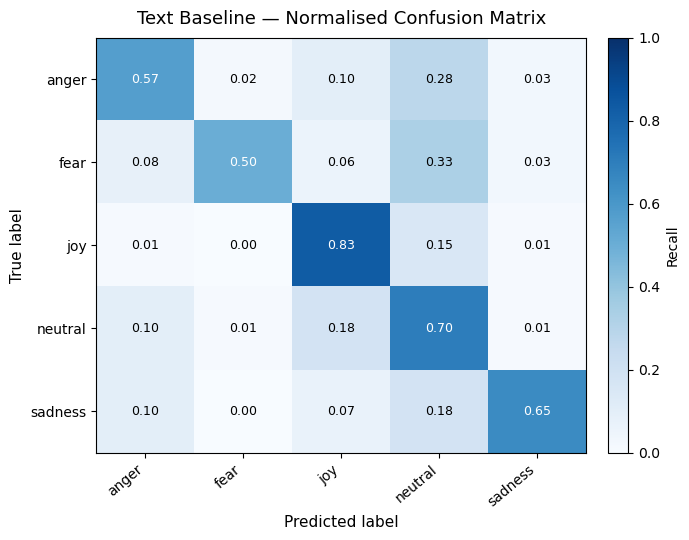

Saved: MER_Project/report_figures/text_confusion_matrix.png


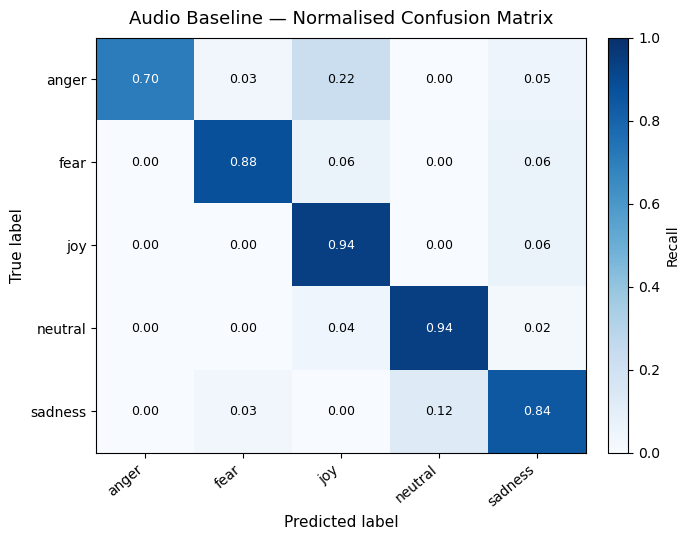

Saved: MER_Project/report_figures/audio_confusion_matrix.png


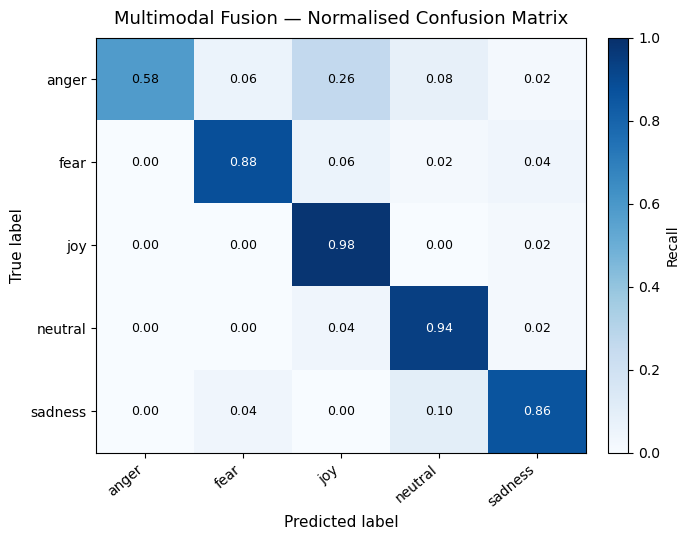

Saved: MER_Project/report_figures/multimodal_confusion_matrix.png


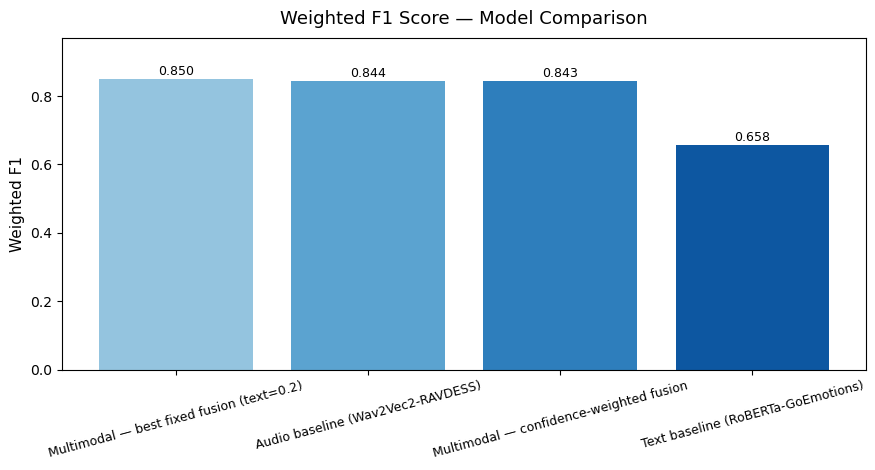

Saved: MER_Project/report_figures/model_comparison_f1.png


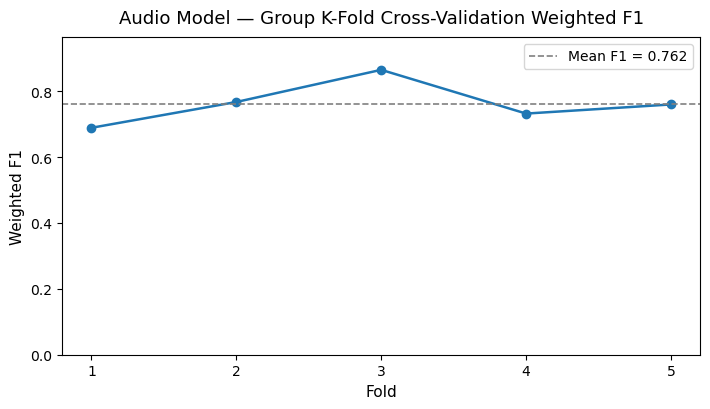

Saved: MER_Project/report_figures/audio_cv_f1_by_fold.png


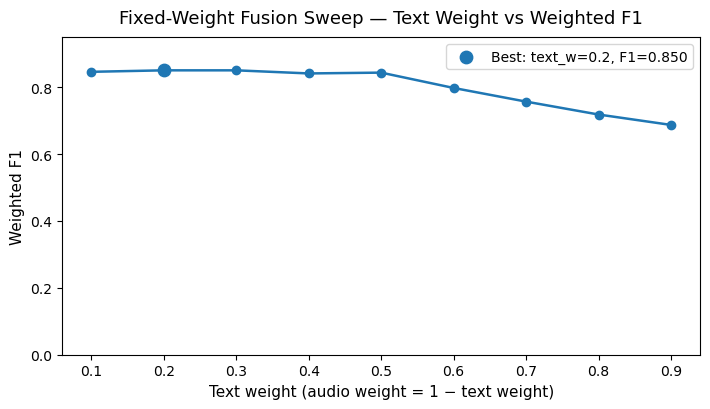

Saved: MER_Project/report_figures/fusion_weight_sweep.png

All figures saved:
  text_cm            : MER_Project/report_figures/text_confusion_matrix.png
  audio_cm           : MER_Project/report_figures/audio_confusion_matrix.png
  multimodal_cm      : MER_Project/report_figures/multimodal_confusion_matrix.png
  comparison         : MER_Project/report_figures/model_comparison_f1.png
  audio_cv           : MER_Project/report_figures/audio_cv_f1_by_fold.png
  weight_sweep       : MER_Project/report_figures/fusion_weight_sweep.png


In [ ]:
REPORT_DIR = PROJECT_DIR / "report_figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _strip_prefix(name):
    """Remove 'true_' or 'pred_' prefix from confusion matrix axis labels."""
    name = str(name)
    return name.split("_", 1)[1] if "_" in name else name


def plot_confusion_matrix_df(cm_df, title, filename, normalize=True):
    """
    Plot and save a confusion matrix.

    Parameters
    ----------
    normalize : bool
        If True, normalise each row to show per-class recall (recommended for reports).
    """
    if cm_df is None or len(cm_df) == 0:
        return None
    values = cm_df.to_numpy(dtype=float)
    if normalize:
        row_sums = values.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        values = values / row_sums

    x_labels = [_strip_prefix(c) for c in cm_df.columns]
    y_labels  = [_strip_prefix(i) for i in cm_df.index]
    vmax      = values.max() if values.size else 1.0

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(values, aspect="auto", cmap="Blues", vmin=0, vmax=1 if normalize else vmax)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label",      fontsize=11)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=40, ha="right", fontsize=10)
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=10)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            txt        = f"{values[i, j]:.2f}" if normalize else f"{int(round(values[i, j]))}"
            text_color = "white" if values[i, j] > 0.6 * vmax else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=text_color)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label="Recall" if normalize else "Count")
    fig.tight_layout()
    out = REPORT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved: {out}")
    return out


def plot_model_comparison(df, filename="model_comparison_f1.png"):
    """Bar chart comparing weighted F1 across all model conditions."""
    if df is None or df.empty:
        return None
    plot_df = df.sort_values("f1", ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    bars = ax.bar(plot_df["model"], plot_df["f1"], color=plt.cm.Blues(
        np.linspace(0.4, 0.85, len(plot_df))))
    ax.set_title("Weighted F1 Score — Model Comparison", fontsize=13, pad=10)
    ax.set_ylabel("Weighted F1", fontsize=11)
    ax.set_ylim(0, min(1.0, float(plot_df["f1"].max()) + 0.12))
    for bar, v in zip(bars, plot_df["f1"]):
        ax.text(bar.get_x() + bar.get_width() / 2, float(v) + 0.012,
                f"{v:.3f}", ha="center", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    plt.xticks(fontsize=9)
    fig.tight_layout()
    out = REPORT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved: {out}")
    return out


def plot_audio_cv_f1(df, filename="audio_cv_f1_by_fold.png"):
    """Line chart of per-fold weighted F1 from audio cross-validation."""
    if df is None or df.empty:
        return None
    plot_df  = df.sort_values("fold")
    mean_f1  = float(plot_df["f1"].mean())
    fig, ax  = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(plot_df["fold"], plot_df["f1"], marker="o", linewidth=1.8, markersize=6)
    ax.axhline(mean_f1, linestyle="--", linewidth=1.2, color="grey",
               label=f"Mean F1 = {mean_f1:.3f}")
    ax.set_title("Audio Model — Group K-Fold Cross-Validation Weighted F1", fontsize=13, pad=10)
    ax.set_xlabel("Fold", fontsize=11)
    ax.set_ylabel("Weighted F1", fontsize=11)
    ax.set_xticks(plot_df["fold"].tolist())
    ax.set_ylim(0, min(1.0, float(plot_df["f1"].max()) + 0.1))
    ax.legend(fontsize=10)
    fig.tight_layout()
    out = REPORT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved: {out}")
    return out


def plot_weight_sweep(df, filename="fusion_weight_sweep.png"):
    """Line chart showing how fixed-weight F1 varies with the text weight parameter."""
    if df is None or df.empty:
        return None
    plot_df  = df.sort_values("text_weight")
    best_row = plot_df.loc[plot_df["f1"].idxmax()]
    fig, ax  = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(plot_df["text_weight"], plot_df["f1"], marker="o", linewidth=1.8, markersize=6)
    ax.scatter([best_row["text_weight"]], [best_row["f1"]], s=80, zorder=5,
               label=f"Best: text_w={best_row['text_weight']:.1f}, F1={best_row['f1']:.3f}")
    ax.set_title("Fixed-Weight Fusion Sweep — Text Weight vs Weighted F1", fontsize=13, pad=10)
    ax.set_xlabel("Text weight (audio weight = 1 − text weight)", fontsize=11)
    ax.set_ylabel("Weighted F1", fontsize=11)
    ax.set_ylim(0, min(1.0, float(plot_df["f1"].max()) + 0.1))
    ax.legend(fontsize=10)
    fig.tight_layout()
    out = REPORT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"Saved: {out}")
    return out


# ── Generate all figures ──────────────────────────────────────────────────────
generated_figures = {}
generated_figures["text_cm"] = plot_confusion_matrix_df(
    text_results["confusion_matrix"],
    "Text Baseline — Normalised Confusion Matrix",
    "text_confusion_matrix.png",
)
generated_figures["audio_cm"] = plot_confusion_matrix_df(
    audio_results["confusion_matrix"],
    "Audio Baseline — Normalised Confusion Matrix",
    "audio_confusion_matrix.png",
)
generated_figures["multimodal_cm"] = plot_confusion_matrix_df(
    multimodal_results["confusion_matrix"],
    "Multimodal Fusion — Normalised Confusion Matrix",
    "multimodal_confusion_matrix.png",
)
generated_figures["comparison"]   = plot_model_comparison(comparison_df)
generated_figures["audio_cv"]     = plot_audio_cv_f1(audio_cv_results)
generated_figures["weight_sweep"] = plot_weight_sweep(weight_sweep_results)

print("\nAll figures saved:")
for key, val in generated_figures.items():
    print(f"  {key:<18} : {val}")
